___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Copyright by Pierian Data Inc.</em></center>
<center><em>For more information, visit us at <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# Principal Component Analysis - Project Exercise Solutions

-----
-----

## GOAL: Figure out which handwritten digits are most differentiated with PCA.

**Imagine you are working on an image recognition service for a postal service. It would be very useful to be able to read in the digits automatically, even if they are handwritten. (Quick note, this is very much how modern postal services work for a long time now and its actually more accurate than a human). The manager of the postal service wants to know which handwritten numbers are the hardest to tell apart, so he can focus on getting more labeled examples of that data. You will have a dataset of hand written digits (a very famous data set) and you will perform PCA to get better insight into which numbers are easily separable from the rest.**

-----
-----

# Data

    Background:

    E. Alpaydin, Fevzi. Alimoglu
    Department of Computer Engineering
    Bogazici University, 80815 Istanbul Turkey
    alpaydin '@' boun.edu.tr


#### Data Set Information from Original Authors:

We create a digit database by collecting 250 samples from 44 writers. The samples written by 30 writers are used for training, cross-validation and writer dependent testing, and the digits written by the other 14 are used for writer independent testing. This database is also available in the UNIPEN format.

We use a WACOM PL-100V pressure sensitive tablet with an integrated LCD display and a cordless stylus. The input and display areas are located in the same place. Attached to the serial port of an Intel 486 based PC, it allows us to collect handwriting samples. The tablet sends $x$ and $y$ tablet coordinates and pressure level values of the pen at fixed time intervals (sampling rate) of 100 miliseconds.

These writers are asked to write 250 digits in random order inside boxes of 500 by 500 tablet pixel resolution. Subject are monitored only during the first entry screens. Each screen contains five boxes with the digits to be written displayed above. Subjects are told to write only inside these boxes. If they make a mistake or are unhappy with their writing, they are instructed to clear the content of a box by using an on-screen button. The first ten digits are ignored because most writers are not familiar with this type of input devices, but subjects are not aware of this.

SOURCE: https://archive.ics.uci.edu/ml/datasets/Pen-Based+Recognition+of+Handwritten+Digits

## Complete the Tasks in bold below

**TASK: Run the cells below to import the libraries and relevant data set.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
digits = pd.read_csv('../DATA/digits.csv')

In [3]:
digits

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,number_label
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0,9
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0,0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0,8
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0,9


**TASK: Create a new DataFrame called *pixels* that consists only of the pixel feature values by dropping the number_label column.**

In [4]:
pixels = digits.drop('number_label',axis=1)

In [5]:
pixels

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


### Displaying an Image

**TASK: Grab a single image row representation by getting the first row of the pixels DataFrame.**

In [6]:
single_image = pixels.iloc[0]

In [7]:
single_image

pixel_0_0     0.0
pixel_0_1     0.0
pixel_0_2     5.0
pixel_0_3    13.0
pixel_0_4     9.0
             ... 
pixel_7_3    13.0
pixel_7_4    10.0
pixel_7_5     0.0
pixel_7_6     0.0
pixel_7_7     0.0
Name: 0, Length: 64, dtype: float64

**TASK: Convert this single row Series into a numpy array.**

In [8]:
single_image.to_numpy()

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

**TASK: Reshape this numpy array into an (8,8) array.**

In [9]:
single_image.to_numpy().shape

(64,)

In [10]:
single_image.to_numpy().reshape(8,8)

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

**TASK: Use Matplotlib or Seaborn to display the array as an image representation of the number drawn. Remember your palette or cmap choice would change the colors, but not the actual pixel values.**

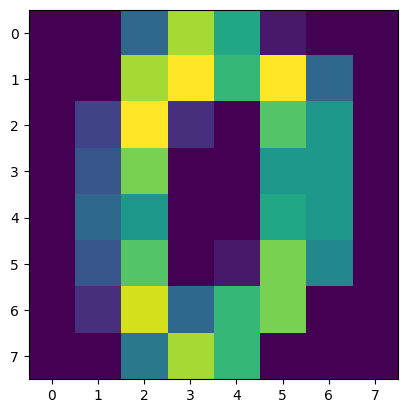

In [11]:
plt.imshow(single_image.to_numpy().reshape(8,8))

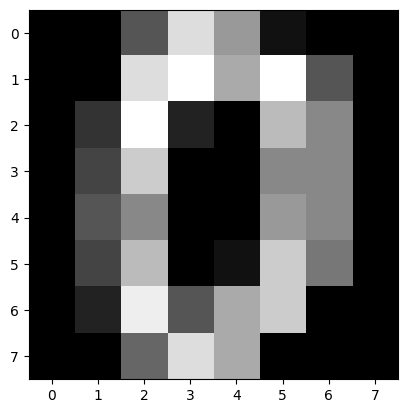

In [12]:
plt.imshow(single_image.to_numpy().reshape(8,8),cmap='gray')

<Axes: >

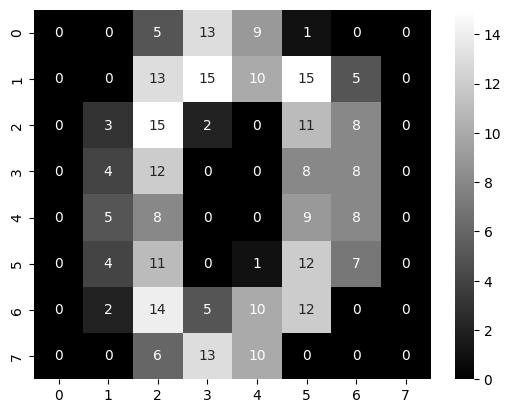

In [13]:
sns.heatmap(single_image.to_numpy().reshape(8,8),annot=True,cmap='gray')

------

Now let's move on to PCA.

## Scaling Data

**TASK: Use Scikit-Learn to scale the pixel feature dataframe.**

In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
scaler = StandardScaler()

In [16]:
scaled_pixels = scaler.fit_transform(pixels)

In [17]:
scaled_pixels

array([[ 0.        , -0.33501649, -0.04308102, ..., -1.14664746,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  0.54856067,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  1.56568555,
         1.6951369 , -0.19600752],
       ...,
       [ 0.        , -0.33501649, -0.88456568, ..., -0.12952258,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -0.67419451, ...,  0.8876023 ,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649,  1.00877481, ...,  0.8876023 ,
        -0.26113572, -0.19600752]], shape=(1797, 64))

## PCA

**TASK: Perform PCA on the scaled pixel data set with 2 components.**

In [18]:
from sklearn.decomposition import PCA

In [19]:
pca_model = PCA(n_components=2)

In [20]:
pca_pixels = pca_model.fit_transform(scaled_pixels)

**TASK: How much variance is explained by 2 principal components.**

In [21]:
np.sum(pca_model.explained_variance_ratio_)

np.float64(0.21594970500832816)

**TASK: Create a scatterplot of the digits in the 2 dimensional PCA space, color/label based on the original number_label column in the original dataset.**

In [22]:
pca_pixels

array([[-1.91421366, -0.95450157],
       [-0.58898033,  0.9246358 ],
       [-1.30203906, -0.31718883],
       ...,
       [-1.02259599, -0.14791087],
       [-1.07605522, -0.38090625],
       [ 1.25770233, -2.22759088]], shape=(1797, 2))

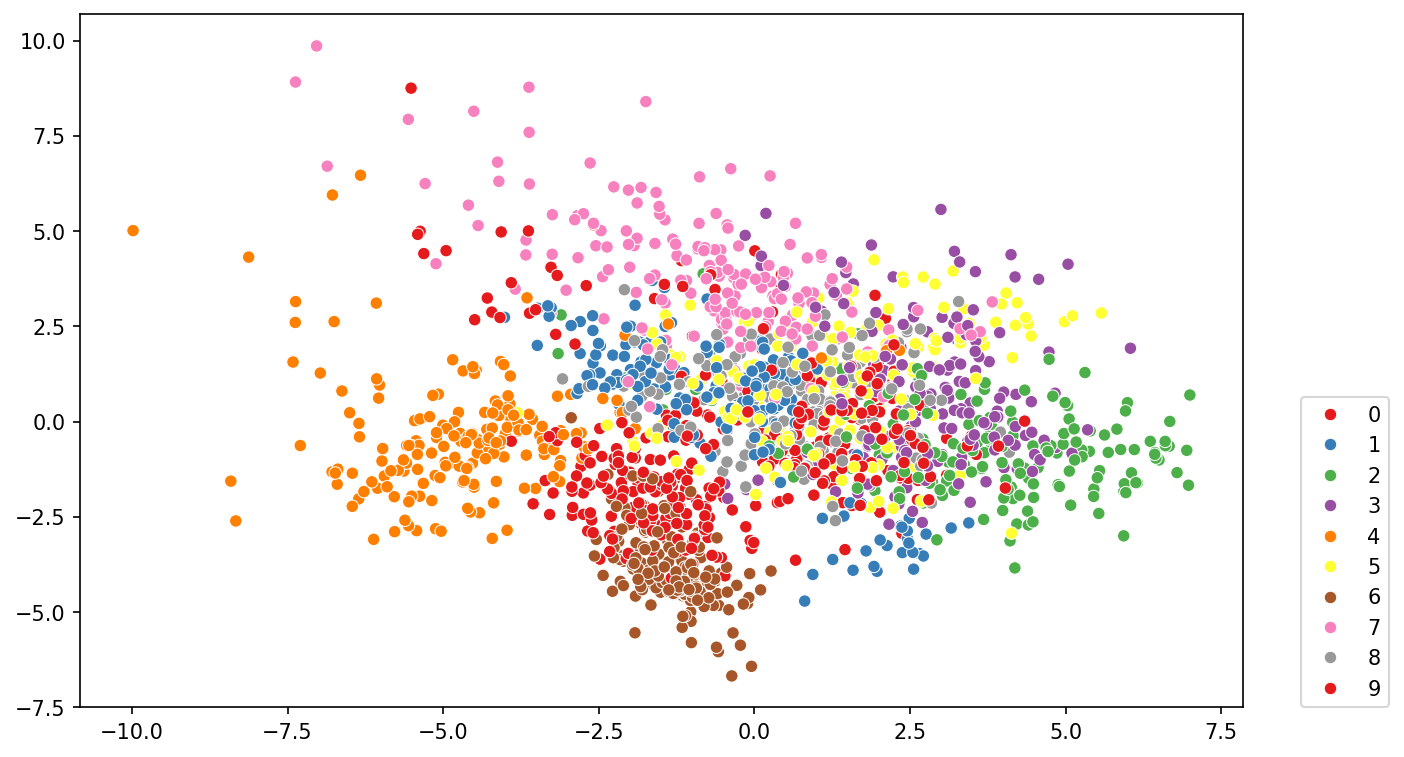

In [23]:
plt.figure(figsize=(10,6),dpi=150)
labels = digits['number_label'].values
sns.scatterplot(x=pca_pixels[:,0],y=pca_pixels[:,1],hue=labels,palette='Set1')
plt.legend(loc=(1.05,0))
plt.show()

C:\Users\Cesar\AppData\Local\Temp\ipykernel_37504\2198254471.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=(1.05,0))


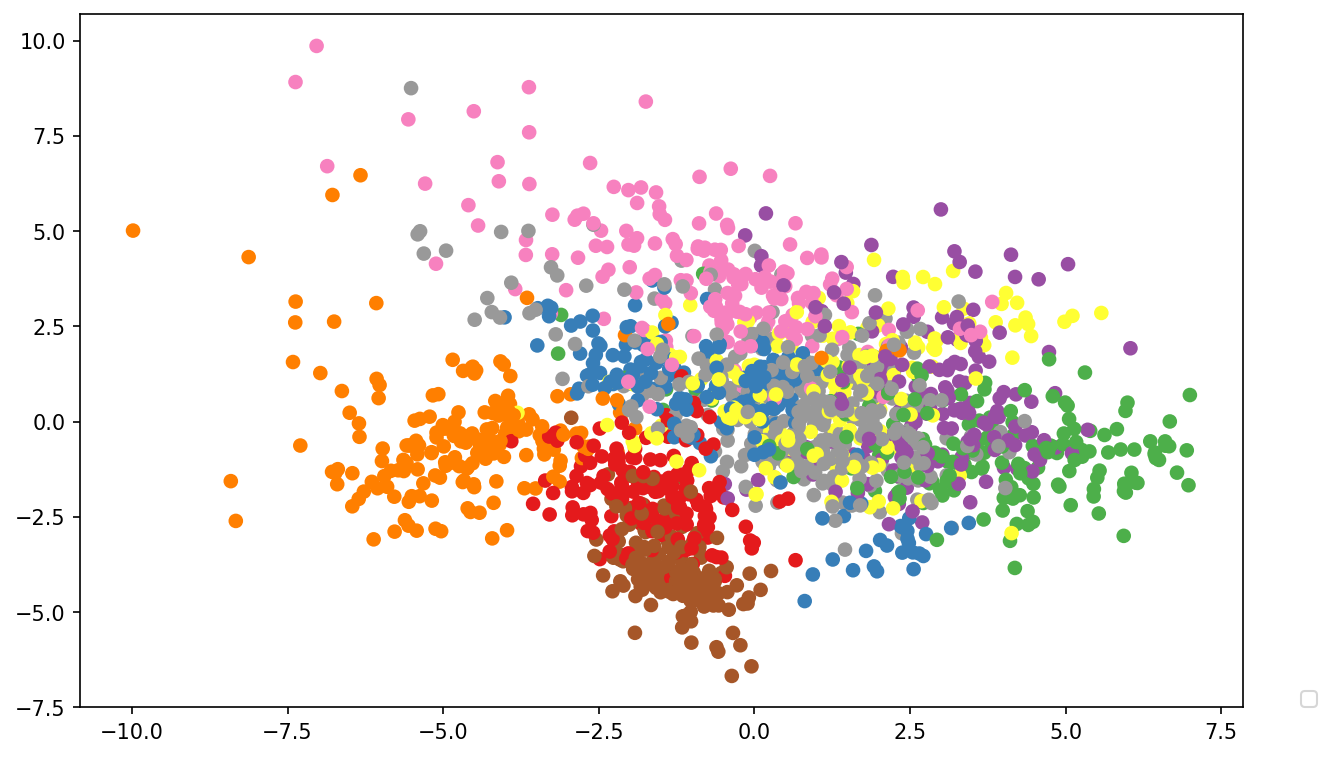

In [24]:
plt.figure(figsize=(10,6),dpi=150)
plt.scatter(pca_pixels[:,0],pca_pixels[:,1],c=labels,cmap='Set1')
plt.legend(loc=(1.05,0))

**TASK: Which numbers are the most "distinct"?**

In [25]:
# You should see label #4 as being the most separated group, 
# implying its the most distinct, similar situation for #2, #6 and #9.

-----------
---------

## Bonus Challenge 

**TASK: Create an "interactive" 3D plot of the result of PCA with 3 principal components. Lot's of ways to do this, including different libraries like plotly or bokeh, but you can actually do this just with Matplotlib and Jupyter Notebook. Search Google and StackOverflow if you get stuck, lots of solutions are posted online.**

In [26]:
from sklearn.decomposition import PCA

In [27]:
pca_model = PCA(n_components=3)

In [28]:
pca_pixels = pca_model.fit_transform(scaled_pixels)

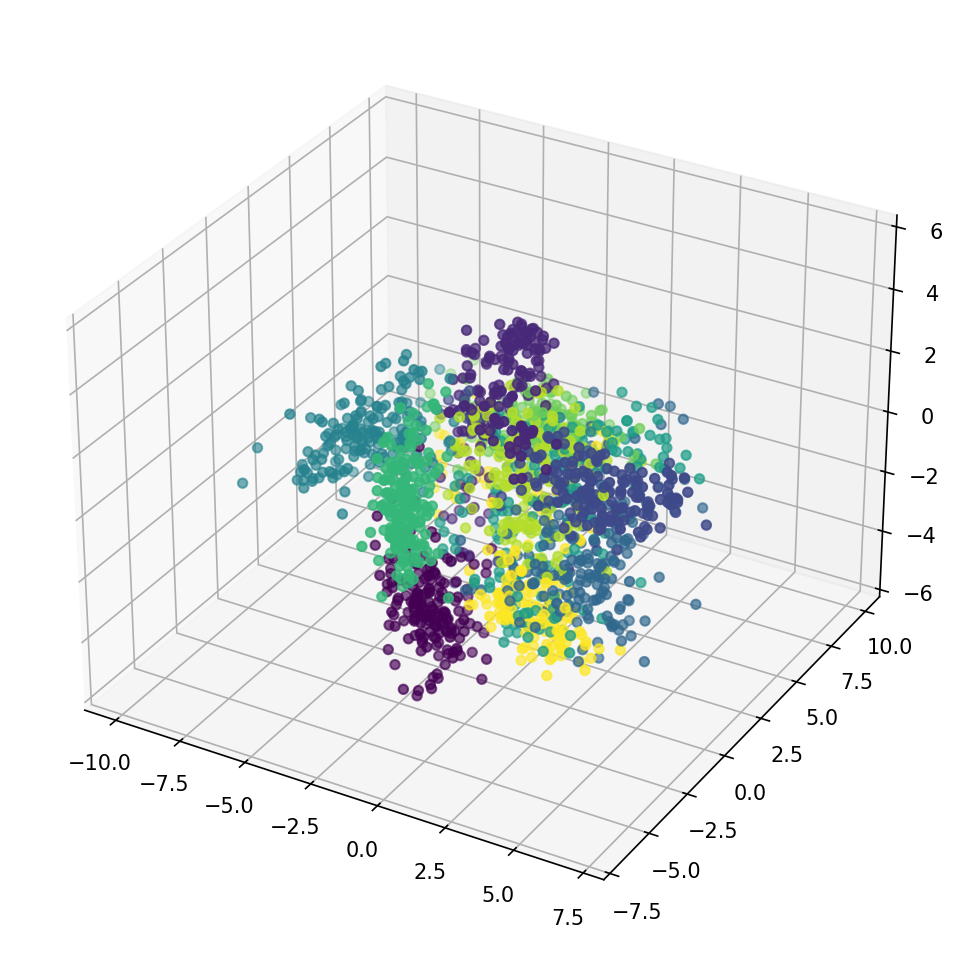

In [29]:
plt.figure(figsize=(8,8),dpi=150)
ax = plt.axes(projection='3d')
ax.scatter3D(pca_pixels[:,0],pca_pixels[:,1],pca_pixels[:,2],c=digits['number_label']);

In [30]:
from mpl_toolkits.mplot3d import Axes3D

In [31]:
import plotly.express as px

fig = px.scatter_3d(x=pca_pixels[:,0], 
                    y=pca_pixels[:,1], 
                    z=pca_pixels[:,2], 
                    color=digits['number_label'].astype(str),
                    title='3D PCA Visualization of Digits Dataset',
                    labels={'PC1': 'First Principal Component', 
                            'PC2': 'Second Principal Component', 
                            'PC3': 'Third Principal Component'},
                    color_discrete_sequence=px.colors.qualitative.Set3,  # Better color palette
                    opacity=0.7,
                    size_max=10
                    )
# Improve layout
fig.update_layout(
    title_font_size=16,
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3',
        bgcolor='rgba(0,0,0,0)',
        xaxis=dict(backgroundcolor='rgba(0,0,0,0)'),
        yaxis=dict(backgroundcolor='rgba(0,0,0,0)'),
        zaxis=dict(backgroundcolor='rgba(0,0,0,0)')
    ),
    width=800,
    height=600,
    margin=dict(r=20, b=10, l=10, t=40)
)

fig.show()

In [32]:
import plotly.graph_objects as go

# Define colors for each digit
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

fig = go.Figure()

# Add each digit as a separate trace for better control
for digit in range(10):
    mask = digits['number_label'] == digit
    fig.add_trace(go.Scatter3d(
        x=pca_pixels[mask, 0],
        y=pca_pixels[mask, 1],
        z=pca_pixels[mask, 2],
        mode='markers',
        marker=dict(
            size=4,
            color=colors[digit],
            opacity=0.8,
            line=dict(width=0.5, color='DarkSlateGray')
        ),
        name=f'Digit {digit}',
        hovertemplate=f'<b>Digit {digit}</b><br>' +
                      'PC1: %{x:.2f}<br>' +
                      'PC2: %{y:.2f}<br>' +
                      'PC3: %{z:.2f}<br>' +
                      '<extra></extra>'
    ))

# Complete layout update
fig.update_layout(
    title='3D PCA Visualization of Handwritten Digits',
    title_x=0.5,
    width=800,
    height=600,
    scene=dict(
        xaxis_title='First Principal Component',
        yaxis_title='Second Principal Component',
        zaxis_title='Third Principal Component',
        camera=dict(
            eye=dict(x=1.2, y=1.2, z=1.2)
        ),
        bgcolor='white',
        xaxis=dict(
            backgroundcolor='rgba(0,0,0,0)',
            gridcolor='lightgray',
            showbackground=True,
            zerolinecolor='gray'
        ),
        yaxis=dict(
            backgroundcolor='rgba(0,0,0,0)',
            gridcolor='lightgray',
            showbackground=True,
            zerolinecolor='gray'
        ),
        zaxis=dict(
            backgroundcolor='rgba(0,0,0,0)',
            gridcolor='lightgray',
            showbackground=True,
            zerolinecolor='gray'
        )
    ),
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

fig.show()


In [33]:
# %matplotlib notebook
# plt.figure(figsize=(8,8),dpi=150)
# ax = plt.axes(projection='3d')
# ax.scatter3D(pca_pixels[:,0],pca_pixels[:,1],pca_pixels[:,2],c=digits['number_label']);
# plt.show()

# Great Job!